In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('mission_launches.csv')  # Replace with your actual filename
print("Dataset loaded!")
print(f"Shape: {df.shape}")

Dataset loaded!
Shape: (4324, 9)


In [2]:
# See first few rows
print(df.head())

   Unnamed: 0.1  Unnamed: 0 Organisation  \
0             0           0       SpaceX   
1             1           1         CASC   
2             2           2       SpaceX   
3             3           3    Roscosmos   
4             4           4          ULA   

                                            Location  \
0         LC-39A, Kennedy Space Center, Florida, USA   
1  Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...   
2                      Pad A, Boca Chica, Texas, USA   
3       Site 200/39, Baikonur Cosmodrome, Kazakhstan   
4           SLC-41, Cape Canaveral AFS, Florida, USA   

                         Date                                        Detail  \
0  Fri Aug 07, 2020 05:12 UTC  Falcon 9 Block 5 | Starlink V1 L9 & BlackSky   
1  Thu Aug 06, 2020 04:01 UTC           Long March 2D | Gaofen-9 04 & Q-SAT   
2  Tue Aug 04, 2020 23:57 UTC            Starship Prototype | 150 Meter Hop   
3  Thu Jul 30, 2020 21:25 UTC  Proton-M/Briz-M | Ekspress-80 & Ekspress-103   
4  

In [3]:
# See data types and null info
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Unnamed: 0.1    4324 non-null   int64
 1   Unnamed: 0      4324 non-null   int64
 2   Organisation    4324 non-null   str  
 3   Location        4324 non-null   str  
 4   Date            4324 non-null   str  
 5   Detail          4324 non-null   str  
 6   Rocket_Status   4324 non-null   str  
 7   Price           964 non-null    str  
 8   Mission_Status  4324 non-null   str  
dtypes: int64(2), str(7)
memory usage: 830.6 KB
None


In [4]:
# Basic statistics
print(df.describe())

       Unnamed: 0.1   Unnamed: 0
count   4324.000000  4324.000000
mean    2161.500000  2161.500000
std     1248.375611  1248.375611
min        0.000000     0.000000
25%     1080.750000  1080.750000
50%     2161.500000  2161.500000
75%     3242.250000  3242.250000
max     4323.000000  4323.000000


In [5]:
# Missing values
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64


In [6]:
# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Duplicates
print(f"\nTotal duplicates: {df.duplicated().sum()}")

# Data shape reminder
print(f"\nData shape: {df.shape}")


Missing values:
Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64

Total duplicates: 0

Data shape: (4324, 9)


In [7]:
# YOUR FINDINGS
print("DATASET SUMMARY:")
print(f"- {df.shape[0]:,} rows")
print(f"- {df.shape[1]} columns")
print(f"- Missing values: {df.isnull().sum().sum()}")
print(f"- Duplicate rows: {df.duplicated().sum()}")
print("\nMain cleaning tasks:")
print("1. [What needs fixing?]")
print("2. [What needs fixing?]")
print("3. [What needs fixing?]")

DATASET SUMMARY:
- 4,324 rows
- 9 columns
- Missing values: 3360
- Duplicate rows: 0

Main cleaning tasks:
1. [What needs fixing?]
2. [What needs fixing?]
3. [What needs fixing?]


In [8]:
# MAKE A COPY SO WE DON'T LOSE ORIGINAL
df_clean = df.copy()

# HANDLE MISSING VALUES
print("Before cleaning:")
print(f"Missing values: {df_clean.isnull().sum().sum()}")

# Drop rows where critical columns are null
df_clean = df_clean.dropna(subset=['Price'])

# Fill other columns
df_clean['Location'] = df_clean['Location'].fillna(0)

print("\nAfter cleaning:")
print(f"Missing values: {df_clean.isnull().sum().sum()}")

Before cleaning:
Missing values: 3360

After cleaning:
Missing values: 0


In [9]:
# REMOVE DUPLICATES
print(f"Before: {len(df_clean)} rows")
df_clean = df_clean.drop_duplicates()
print(f"After: {len(df_clean)} rows")

Before: 964 rows
After: 964 rows


In [10]:
# FIX DATA TYPES - Handle mixed formats, mixed timezones, and bad data
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='mixed', utc=True, errors='coerce')

# Check results
failed_dates = df_clean['Date'].isnull().sum()
print(f"Dates successfully converted: {len(df_clean) - failed_dates}")
print(f"Dates that couldn't be parsed: {failed_dates}")
print(f"Sample of converted dates:")
print(df_clean['Date'].head())

df_clean.info()

Dates successfully converted: 964
Dates that couldn't be parsed: 0
Sample of converted dates:
0   2020-08-07 05:12:00+00:00
1   2020-08-06 04:01:00+00:00
3   2020-07-30 21:25:00+00:00
4   2020-07-30 11:50:00+00:00
5   2020-07-25 03:13:00+00:00
Name: Date, dtype: datetime64[us, UTC]
<class 'pandas.DataFrame'>
Index: 964 entries, 0 to 4020
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Unnamed: 0.1    964 non-null    int64              
 1   Unnamed: 0      964 non-null    int64              
 2   Organisation    964 non-null    str                
 3   Location        964 non-null    str                
 4   Date            964 non-null    datetime64[us, UTC]
 5   Detail          964 non-null    str                
 6   Rocket_Status   964 non-null    str                
 7   Price           964 non-null    str                
 8   Mission_Status  964 non-null    str                
d

In [11]:
# Get the year from each date
df_clean['Year'] = df_clean['Date'].dt.year

# Count launches per year
launches_per_year = df_clean['Year'].value_counts().sort_index()
print(launches_per_year)

Year
1964     2
1965     2
1966     3
1967     8
1968    10
1969     8
1970     1
1971     2
1972     2
1973     1
1981     2
1982     4
1983     5
1984     6
1985    10
1986     3
1987     3
1988     5
1989     6
1990    11
1991     7
1992    12
1993    12
1994    16
1995    10
1996    14
1997    18
1998    18
1999    14
2000    16
2001    10
2002    17
2003    20
2004    17
2005    15
2006    27
2007    29
2008    28
2009    31
2010    29
2011    29
2012    25
2013    33
2014    41
2015    39
2016    64
2017    66
2018    88
2019    73
2020    52
Name: count, dtype: int64


In [12]:
# HISTOGRAM - Distribution of launch years
plt.figure(figsize=(10, 5))
plt.hist(df_clean['Date'].dt.year, bins=20, edgecolor='black')
plt.title('Distribution of Launches by Year')
plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [13]:
plt.figure(figsize=(12, 6))
top_orgs = df_clean['Organisation'].value_counts().head(10)
top_orgs.plot(kind='bar')
plt.title('Top 10 Space Organizations by Number of Launches')
plt.xlabel('Organization')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [14]:
plt.figure(figsize=(8, 8))
df_clean['Mission_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Mission Success Rate')
plt.ylabel('')
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

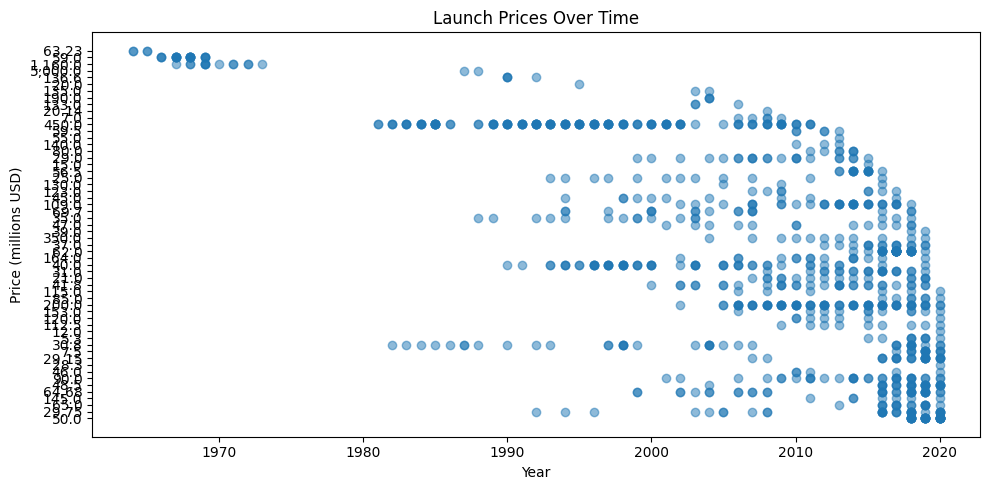

In [15]:
import matplotlib.pyplot as plt

# SCATTER PLOT - Did launch prices change over time?
plt.figure(figsize=(10, 5))
plt.scatter(df_clean['Date'].dt.year, df_clean['Price'], alpha=0.5)
plt.title('Launch Prices Over Time')
plt.xlabel('Year')
plt.ylabel('Price (millions USD)')
plt.tight_layout()
plt.show()

In [16]:
# Check what type Price is
print("Current type of Price column:")
print(df_clean['Price'].dtype)
print("\nSample values:")
print(df_clean['Price'].head(10))

Current type of Price column:
str

Sample values:
0      50.0
1     29.75
3      65.0
4     145.0
5     64.68
6      48.5
8      50.0
9      90.0
10     46.0
11     28.3
Name: Price, dtype: str


In [17]:
# Convert Price to a number (handles text-formatted numbers)
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors='coerce')

# Now check
print("After conversion:")
print(df_clean['Price'].dtype)
print(df_clean['Price'].describe())

After conversion:
float64
count    949.000000
mean     129.795237
std      143.220323
min        5.300000
25%       40.000000
50%       62.000000
75%      164.000000
max      450.000000
Name: Price, dtype: float64


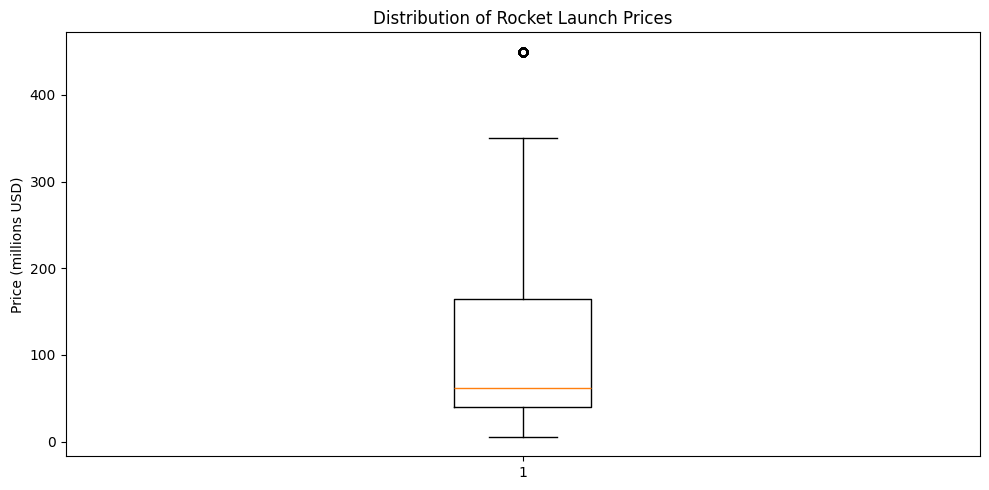

In [18]:
import matplotlib.pyplot as plt

# BOX PLOT - Show outliers in rocket prices
plt.figure(figsize=(10, 5))
plt.boxplot(df_clean['Price'].dropna())
plt.title('Distribution of Rocket Launch Prices')
plt.ylabel('Price (millions USD)')
plt.tight_layout()
plt.show()

In [19]:
# Convert Price to a number
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors='coerce')
print(f"Price column type: {df_clean['Price'].dtype}")
print(f"Number of valid prices: {df_clean['Price'].notna().sum()}")
print(f"Number of missing prices: {df_clean['Price'].isna().sum()}")

Price column type: float64
Number of valid prices: 949
Number of missing prices: 15


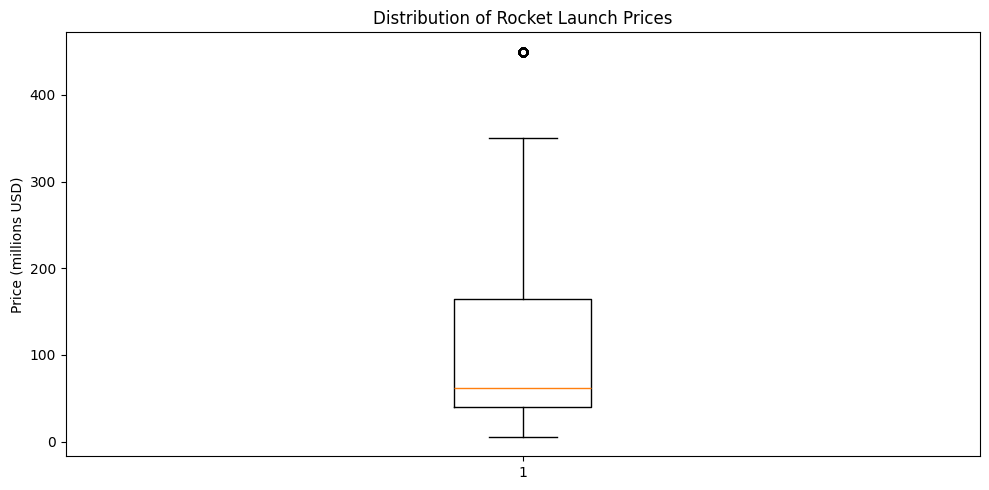

In [20]:
import matplotlib.pyplot as plt

# BOX PLOT - Show outliers in rocket prices
plt.figure(figsize=(10, 5))
plt.boxplot(df_clean['Price'].dropna())
plt.title('Distribution of Rocket Launch Prices')
plt.ylabel('Price (millions USD)')
plt.tight_layout()
plt.show()

In [21]:
# Save cleaned data for Tableau
df_clean.to_csv('mission_launches_cleaned.csv', index=False)
print("Saved! File location:", )

import os
print(os.getcwd())  # Shows where the file was saved

Saved! File location:
C:\Users\blsst\analytics\Month-1
